In [ ]:
#loading data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

air_df = pd.read_csv("Air_Traffic_Passenger_Statistics (2).csv")
tourism_df = pd.read_csv("world_tourism_economy_data (1).csv")

In [ ]:
#Data Preprocessing

In [ ]:
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', None)   
pd.set_option('display.width', None) 

In [ ]:
air_df.columns = air_df.columns.str.strip().str.lower().str.replace(" ", "_")
tourism_df.columns = tourism_df.columns.str.strip().str.lower().str.replace(" ", "_")

In [ ]:
print(air_df.columns)

In [ ]:
air_df['activity_period_start_date'] = pd.to_datetime(air_df['activity_period_start_date'], errors='coerce')
air_df['year'] = air_df['activity_period_start_date'].dt.year

In [ ]:
air_df['passenger_count'] = pd.to_numeric(air_df['passenger_count'], errors='coerce')

In [ ]:
asia_air_df = air_df[air_df['geo_region'].str.contains('Asia', case=False, na=False)]
asia_air_df = asia_air_df[['year', 'geo_summary', 'geo_region', 'passenger_count']]
asia_air_df

In [ ]:
tourism_cols = ['tourism_receipts','tourism_arrivals','tourism_exports','tourism_departures','tourism_expenditures','gdp','inflation','unemployment']
for col in tourism_cols:
    tourism_df[col] = pd.to_numeric(tourism_df[col], errors='coerce')
tourism_cols

In [ ]:
asia_countries = [
    'India', 'China', 'Japan', 'South Korea', 'Indonesia', 'Malaysia',
    'Thailand', 'Singapore', 'Philippines', 'Vietnam', 'Sri Lanka',
    'Nepal', 'Pakistan', 'Bangladesh', 'United Arab Emirates', 'Saudi Arabia',
    'Qatar', 'Kuwait', 'Oman', 'Iran', 'Turkey']
asia_tourism_df = tourism_df[tourism_df['country'].isin(asia_countries)]
asia_tourism_df

In [ ]:
asia_air_df = asia_air_df.dropna(subset=['year', 'passenger_count'])
asia_tourism_df = asia_tourism_df.dropna(subset=['year', 'country'])
asia_tourism_df

In [ ]:
asia_air_yearly = (asia_air_df.groupby('year')['passenger_count'].sum().reset_index().rename(columns={'passenger_count': 'asia_total_passengers'}))
asia_air_yearly

In [ ]:
tourism_cols = [
    'tourism_receipts',
    'tourism_arrivals',
    'tourism_exports',
    'tourism_departures',
    'tourism_expenditures',
    'gdp',
    'inflation',
    'unemployment']

for col in tourism_cols:
    asia_tourism_df[col] = asia_tourism_df[col].fillna(asia_tourism_df[col].median())
tourism_cols

In [ ]:
asia_tourism_yearly = (asia_tourism_df.groupby('year')[tourism_cols].sum().reset_index())
asia_tourism_yearly


In [ ]:
asia_combined_df = pd.merge(asia_air_yearly,asia_tourism_yearly,on='year',how='inner')
asia_combined_df

In [ ]:
print("Asia Air Years:", asia_air_yearly['year'].min(), "-", asia_air_yearly['year'].max())
print("Asia Tourism Years:", asia_tourism_yearly['year'].min(), "-", asia_tourism_yearly['year'].max())
print("Merged Asia Years:", asia_combined_df['year'].min(), "-", asia_combined_df['year'].max())


In [ ]:
asia_combined_df = asia_combined_df.sort_values('year').reset_index(drop=True)
asia_combined_df

In [ ]:
# OBJECTIVE 1 - Year-wise Air Passenger Traffic in Asia
# Analyzing year-wise air passenger traffic in Asia to understand how passenger volumes change over time, identify years with the highest and lowest traffic, and detect periods of major growth or sharp decline in air travel.

In [ ]:
# Inspect Final Asia air yearly data
asia_air_yearly

In [ ]:
# How has air passenger traffic changed year by year ?

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(asia_air_yearly["year"],asia_air_yearly["asia_total_passengers"],marker = 'o')
plt.title("Year-wise Air Passenger Traffic in Asia")
plt.xlabel("Year")
plt.ylabel("Total Air Passengers")
plt.show()

In [ ]:
# Insights:
# Air passenger traffic in Asia shows a clear long-term upward trend from the early 2000s to 2019, reflecting rising population, income levels, and air connectivity.
# A sharp collapse in 2020–2021 is clearly visible, corresponding to COVID-19 travel restrictions, making this the largest disruption in the entire timeline.
# Post-2021, passenger traffic rebounds strongly, indicating pent-up demand and gradual reopening of international and domestic travel.
# The highest passenger volume in 2024 suggests recovery momentum rather than organic growth alone, highlighting a post-pandemic normalization phase.

In [ ]:
# Which years had the highest and lowest passenger numbers?

highest_air_year = asia_air_yearly.loc[asia_air_yearly["asia_total_passengers"].idxmax()]
lowest_air_year = asia_air_yearly.loc[asia_air_yearly["asia_total_passengers"].idxmin()]
highest_air_year, lowest_air_year

In [ ]:
# When did Asia see major growth or sharp drops in air travel?
asia_air_yearly["yoy_change_passengers"] = (asia_air_yearly["asia_total_passengers"].pct_change()*100)
asia_air_yearly

In [ ]:
# PLoting Year over year change(growth and drops)
plt.figure()
plt.plot(asia_air_yearly['year'],asia_air_yearly['yoy_change_passengers'],marker = 'o')
plt.axhline(0)
plt.title('YOY change in Asia Air Passenger Traffic')
plt.xlabel('Year')
plt.ylabel('YoY change (%)')
plt.show()

In [ ]:
# Insights:
# Most years show moderate positive YoY growth, indicating steady expansion rather than volatile fluctuations under normal conditions.
# The extreme negative YoY drop in 2020 confirms the unprecedented impact of COVID-19 on air travel.
# The very high positive YoY growth in 2022–2023 reflects a rebound effect, not structural growth, as travel resumed after lockdowns.
# YoY volatility increases significantly after 2019, showing that the aviation sector became highly sensitive to global shocks.

In [ ]:
# Objective 2 - Tourism Trends in Asia
# Examining changes in Asia’s tourism activity over the years by identifying years that experienced significant increases or decreases in tourism performance.
asia_air_yearly

In [ ]:
# Which years showed major increases or declines?
asia_tourism_yearly["yoy_arrivals_change"] = (asia_tourism_yearly["tourism_arrivals"].pct_change() * 100)
asia_tourism_yearly[["year", "tourism_arrivals", "yoy_arrivals_change"]]

In [ ]:
# Plot YoY change in tourist arrivals
plt.figure()
plt.plot(asia_tourism_yearly["year"],asia_tourism_yearly["yoy_arrivals_change"],marker = 'o')
plt.axhline(0)
plt.title("Year-over-Year Change in Tourist Arrivals (Asia)")
plt.xlabel("Year")
plt.ylabel("YoY Change (%)")
plt.show()

In [ ]:
# Insights:
# Before 2019, YoY changes mostly remain positive but moderate, indicating sustainable tourism growth.
# Occasional negative dips reflect temporary global or regional disturbances, not long-term decline.
# The massive negative YoY drop in 2020 clearly marks the COVID-19 shock as an outlier event.
# Near-zero or low YoY growth after 2021 suggests slow international tourism revival, despite easing restrictions.

In [ ]:
# objective:3
# Comparing Asia’s air passenger traffic with tourism activity and earnings to see whether changes in aviation are linked to tourism performance.

In [56]:
# Is there a connection between passenger traffic and tourism earnings?
corr = asia_combined_df["asia_total_passengers"].corr(asia_combined_df["tourism_receipts"])
print("Correlation between Air Passengers and Tourism Earnings:", round(corr, 2))

Correlation between Air Passengers and Tourism Earnings: 0.68


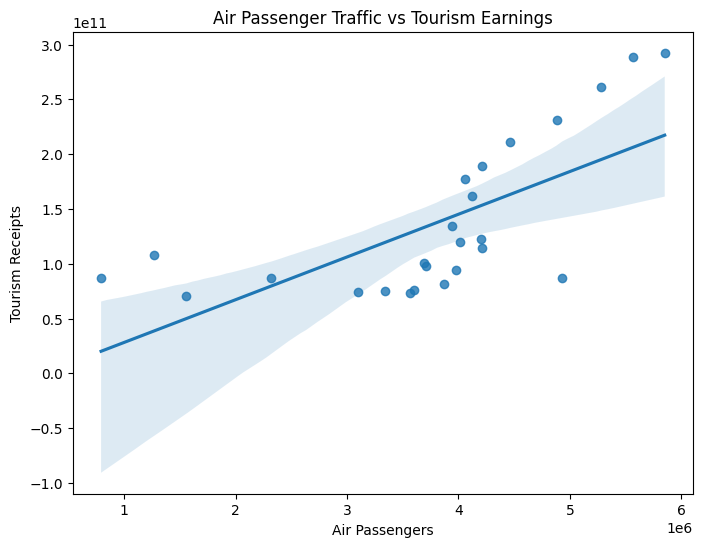

In [57]:
plt.figure(figsize=(8,6))
sns.regplot(x="asia_total_passengers",y="tourism_receipts",data=asia_combined_df)
plt.title("Air Passenger Traffic vs Tourism Earnings")
plt.xlabel("Air Passengers")
plt.ylabel("Tourism Receipts")
plt.show()


In [ ]:
# Insights: 
# The scatter plot shows a clear positive relationship between air passenger traffic and tourism earnings. 
# As passenger numbers increase, tourism revenue also rises, although spending per tourist varies due to economic and behavioral factors.


In [58]:
# Do rises or falls in air travel show similar changes in tourism performance?
asia_combined_df["passenger_growth"] = asia_combined_df["asia_total_passengers"].pct_change()*100
asia_combined_df["arrival_growth"] = asia_combined_df["tourism_arrivals"].pct_change()*100
asia_combined_df["receipt_growth"] = asia_combined_df["tourism_receipts"].pct_change()*100

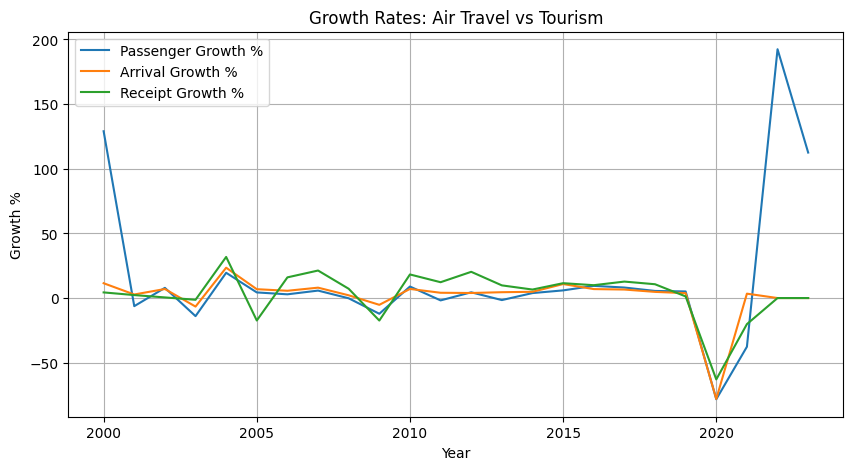

In [59]:
plt.figure(figsize=(10,5))
plt.plot(asia_combined_df["year"], asia_combined_df["passenger_growth"], label="Passenger Growth %")
plt.plot(asia_combined_df["year"], asia_combined_df["arrival_growth"], label="Arrival Growth %")
plt.plot(asia_combined_df["year"], asia_combined_df["receipt_growth"], label="Receipt Growth %")

plt.title("Growth Rates: Air Travel vs Tourism")
plt.xlabel("Year")
plt.ylabel("Growth %")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Insights:
# The growth rate trends show that increases and decreases in air travel are mirrored by similar changes in tourism performance, proving that tourism activity strongly depends on air passenger movement.     

In [ ]:
# objective 4 
# Examining the impact of economic indicators such as GDP, inflation, and unemployment on travel and tourism in Asia. 

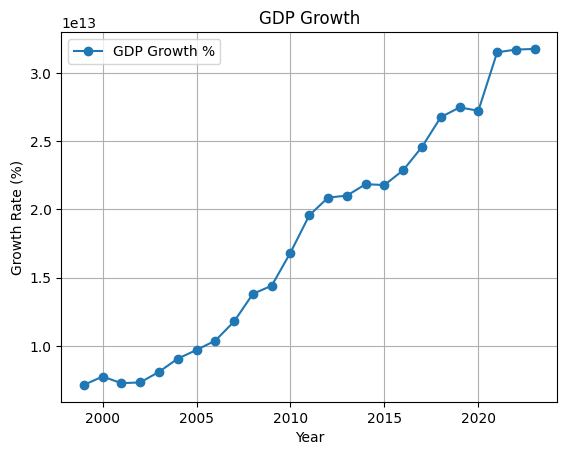

In [60]:
# Does GDP growth match increases in air travel and tourism activity?
asia_combined_df[["gdp"]].corr().round(2)
plt.plot(asia_combined_df["year"], asia_combined_df["gdp"], marker='o', label="GDP Growth %")

plt.title("GDP Growth")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

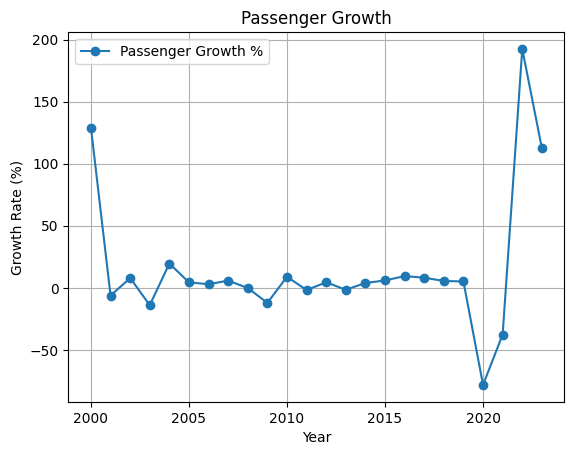

In [61]:
asia_combined_df[["passenger_growth"]].corr().round(2)
plt.plot(asia_combined_df["year"], asia_combined_df["passenger_growth"], marker='o', label="Passenger Growth %")

plt.title("Passenger Growth")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

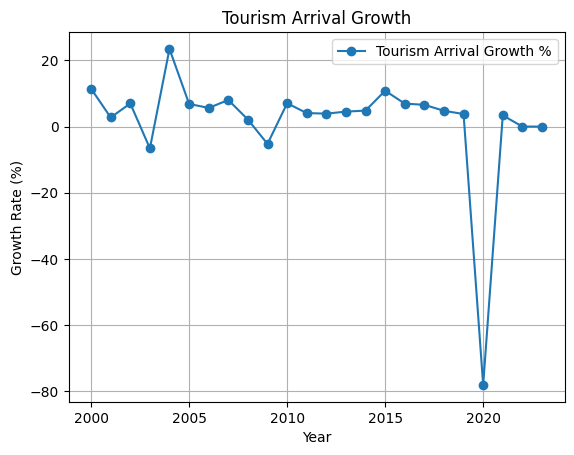

In [62]:
asia_combined_df[["arrival_growth"]].corr().round(2)
plt.plot(asia_combined_df["year"], asia_combined_df["arrival_growth"], marker='o', label="Tourism Arrival Growth %")

plt.title("Tourism Arrival Growth")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Insights
# When GDP growth is strong, passenger traffic usually increases,Tourism arrivals also tend to grow.
# Passenger and tourism growth lines show bigger ups and downs than GDP.
# In 2020 GDP growth declines, Passenger growth drops sharply, Tourism arrival growth collapses even more     

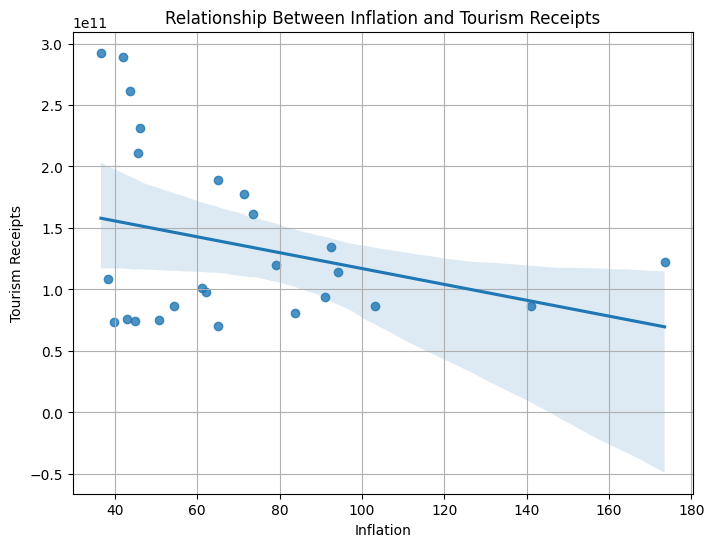

In [63]:
# How does inflation affect tourism spending?
asia_combined_df[["inflation","tourism_receipts"]].corr().round(2)
plt.figure(figsize=(8,6))
sns.regplot(x="inflation",y="tourism_receipts",data=asia_combined_df)
plt.title("Relationship Between Inflation and Tourism Receipts")
plt.xlabel("Inflation")
plt.ylabel("Tourism Receipts")
plt.grid(True)
plt.show()

In [ ]:
# Insights:
# As inflation increases, tourism receipts tend to decrease.
# This suggests that higher price levels make travel more expensive, which can reduce overall tourism spending.
# High inflation can negatively affect tourism revenue because rising costs discourage tourist spending.

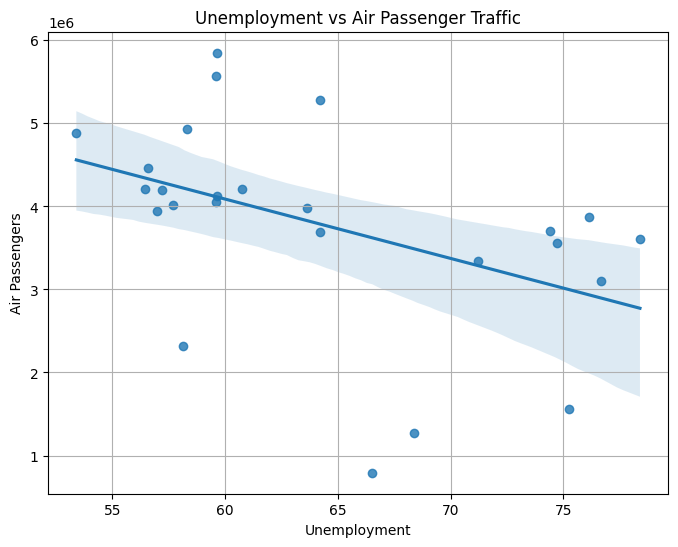

In [64]:
# Does higher unemployment reduce travel and tourism activity?
asia_combined_df[["unemployment","asia_total_passengers","tourism_receipts"]].corr().round(2)
# Unemployment vs Air Passengers:

plt.figure(figsize=(8,6))
sns.regplot(x="unemployment",y="asia_total_passengers",data=asia_combined_df)
plt.title("Unemployment vs Air Passenger Traffic")
plt.xlabel("Unemployment")
plt.ylabel("Air Passengers")
plt.grid(True)
plt.show()

In [ ]:
# Insights:
# The trendline slopes downward
# As unemployment increases, air passenger numbers decrease.
# When more people are unemployed, fewer people can afford to travel, leading to reduced air passenger traffic.

In [ ]:
# Unemployment vs Tourism Receipts
plt.figure(figsize=(8,6))
sns.regplot(x="unemployment",y="tourism_receipts",data=asia_combined_df)
plt.title("Unemployment Rate vs Tourism Receipts")
plt.xlabel("Unemployment")
plt.ylabel("Tourism Receipts")
plt.grid(True)
plt.show()

In [ ]:
# Insights:
# Higher unemployment is associated with lower tourism spending
# Unemployment reduces disposable income, so people cut back on non-essential spending like vacations and tourism.

In [ ]:
# Objective 5 
# Analyzing year-over-year growth in air passengers, tourism activity, and GDP to identify recovery periods and understand growth stability.

In [ ]:
# Which years show recovery after a decline?

recovery_table = asia_combined_df[
    ((asia_combined_df["passenger_growth"].shift(1) < 0) & (asia_combined_df["passenger_growth"] > 0)) |
    ((asia_combined_df["arrival_growth"].shift(1) < 0) & (asia_combined_df["arrival_growth"] > 0)) |
    ((asia_combined_df["gdp"].shift(1) < 0) & (asia_combined_df["gdp"] > 0))
][["year", "passenger_growth", "arrival_growth", "gdp"]]

recovery_table

In [ ]:
#2002 & 2004
# Recovery after early-2000s global shocks - aviation slump period.
# 2010
# Recovery after the 2008–09 global financial crisis dip.
# 2012 & 2014
# Steady recoveries more like growth resuming after slowdowns, not major crises.
# 2021
#Passenger growth still negative (-37%)
#Tourism arrivals positive
#Tourism started recovering before air travel fully stabilized.
2022
#Massive passenger growth (192%)
# Post-COVID rebound effect.

#GDP insight
# Economic recovery is smoother and slower
# Aviation & tourism are more shock-sensitive and volatile

In [ ]:
# Objective 6
# Using basic statistical analysis to summarize overall trends, variation, and performance of Asia’s travel and tourism industry.

In [ ]:
# What are the average numbers of passengers, tourist arrivals, and tourism earnings in Asia?
asia_combined_df[['asia_total_passengers', 'tourism_arrivals', 'tourism_receipts']].mean()

In [ ]:
# How much do air travel and tourism figures vary over time?
asia_combined_df[['asia_total_passengers', 'tourism_arrivals', 'tourism_receipts']].std()

In [ ]:
# What are the highest values seen in key travel indicators?
asia_combined_df[['asia_total_passengers', 'tourism_arrivals', 'tourism_receipts']].max()

In [ ]:
# What are the lowest values seen in key travel indicators?
asia_combined_df[['asia_total_passengers', 'tourism_arrivals', 'tourism_receipts']].min()

In [ ]:
asia_combined_df[['asia_total_passengers', 
                  'tourism_arrivals', 
                  'tourism_receipts']].describe()


In [ ]:
# Objective 7
# Exploring long-term trends in Asia’s travel activity through visualizations and overall trend patterns.
# Country-wise Comparison of Tourism Indicators in Asia
country_tourism = (asia_tourism_df.groupby('country')[['tourism_arrivals','tourism_receipts','tourism_expenditures']].sum().sort_values(by='tourism_receipts', ascending=False))
country_tourism

In [ ]:
country_tourism.head(8).plot(kind='bar', figsize=(10,5))
plt.title('Country-wise Comparison of Tourism Indicators in Asia')
plt.ylabel('Total Value')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# the top contributors to Asia’s tourism economy
top5 = country_tourism.head(5)
top5

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(top5['tourism_receipts'],labels=top5.index,autopct='%1.2f%%')
plt.title("Top 5 Asian Countries by Tourism Receipts Share") 
plt.show()

In [ ]:
# How strong is the relationship between air passenger traffic and tourism indicators?

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(asia_combined_df['year'], asia_combined_df['asia_total_passengers'], marker='o', color='blue')
plt.title('Long-Term Trend of Air Passengers in Asia')
plt.xlabel('Year')
plt.ylabel('Total Air Passengers (Asia)')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(asia_combined_df['year'], asia_combined_df['tourism_receipts'], marker='o', color='green')
plt.title('Long-Term Trend of Tourism Receipts in Asia')
plt.xlabel('Year')
plt.ylabel('Tourism Receipts (Asia)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(asia_combined_df['year'], asia_combined_df['tourism_arrivals'], marker='o', color='red')
plt.title('Long-Term Trend of Tourism Arrivals in Asia')
plt.xlabel('Year')
plt.ylabel('Tourism Arrivals (Asia)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Insights
# Air Passenger Trend — Air passenger traffic in Asia grew steadily over the years, dropped sharply in 2020, and then began recovering.
# Tourism Receipts Trend — Tourism earnings rose consistently until 2019, fell drastically in 2020, and are recovering slowly.
# Tourism Arrivals Trend — Tourist arrivals showed strong long-term growth before a major collapse in 2020.
# Recovery Pattern — Air travel is recovering faster than tourism arrivals and earnings.

In [ ]:
tourism_indicators = [
    'tourism_receipts',
    'tourism_arrivals',
    'tourism_exports',
    'tourism_departures',
    'tourism_expenditures',
    'gdp',
    'inflation',
    'unemployment']


correlation_cols = ['asia_total_passengers'] + tourism_indicators
correlation_df = asia_combined_df[correlation_cols]
correlation_matrix = correlation_df.corr(method='pearson')
passenger_correlations = correlation_matrix['asia_total_passengers'][tourism_indicators]

print("Pearson Correlation with asia_total_passengers:")
print(passenger_correlations)

In [ ]:
plt.figure(figsize=(20, 15))

strong_moderate_indicators = [
    'tourism_arrivals',
    'tourism_departures',
    'tourism_receipts',
    'tourism_expenditures',
    'tourism_exports',
    'unemployment'
]

for i, col in enumerate(strong_moderate_indicators):
    plt.subplot(2, 3, i + 1)
    sns.regplot(x=col, y='asia_total_passengers', data=asia_combined_df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.title(f'Asia Total Passengers vs. {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Asia Total Passengers')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#Insights
#Passengers Vs Arrivals — Air passenger traffic shows a strong positive relationship with tourism arrivals.
#Passengers Vs Departures — Higher passenger volumes are closely linked with increased tourism departures.
#Passengers Vs Receipts — Tourism earnings rise as air passenger traffic increases, showing economic dependence on aviation.
#Passengers Vs Expenditures — Tourism spending grows alongside increases in passenger traffic.
#Passengers Vs Exports — Tourism export value is positively associated with higher air passenger movement.
#Passengers Vs Unemployment — Passenger traffic tends to decline when unemployment rises, indicating an inverse relationship.